In [5]:
import pandas as pd
import pandas as pdb

In [7]:
optimised_hydra_results = pd.read_csv("../optimised_hydra_summary.csv")

In [8]:
datasets_for_optimisation = optimised_hydra_results[["dataset", "series_length"]].drop_duplicates().sort_values("series_length")["dataset"].tolist()

In [9]:
subsamples = datasets_for_optimisation[:5] + datasets_for_optimisation[5:-5:20] + datasets_for_optimisation[-5:]

In [10]:
optimised_hydra_results[optimised_hydra_results["dataset"] == "HandOutlines"]

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
112,HandOutlines,mps_hydra,42,1000,370,2709,2,16.283458,-722.567168,0.948649,0.943157,0.948123,ok,NaN
113,HandOutlines,cpu_optimised_hydra,42,1000,370,2709,2,15.895860,203.603968,0.948649,0.943157,0.948123,ok,NaN


In [12]:
optimised_hydra_results[optimised_hydra_results["dataset"] == "SmoothSubspace"]

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
208,SmoothSubspace,mps_hydra,42,150,150,15,3,0.049608,11.517952,0.96,0.959997,0.959997,ok,NaN
209,SmoothSubspace,cpu_optimised_hydra,42,150,150,15,3,0.029043,0.000000,0.96,0.959997,0.959997,ok,NaN


In [13]:
subsamples

['SmoothSubspace',
 'MelbournePedestrian',
 'ItalyPowerDemand',
 'Chinatown',
 'Crop',
 'SyntheticControl',
 'SwedishLeaf',
 'InsectWingbeatSound',
 'FaceFour',
 'AllGestureWiimoteY',
 'UWaveGestureLibraryAll',
 'PigCVP',
 'PigArtPressure',
 'PigAirwayPressure',
 'HandOutlines',
 'Rock']

In [15]:
optimal_seq_len = pd.read_csv("../optimal_sequence_length.csv")

In [16]:
optimal_seq_len.head()

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg,sequence_length
0,SmoothSubspace,mps_hydra,42,150,150,15,3,0.108357,81.772544,0.960000,0.959997,0.959997,ok,NaN,1600
1,MelbournePedestrian,mps_hydra,42,1138,2319,24,10,0.311521,192.610304,0.937904,0.935075,0.937820,ok,NaN,1600
2,ItalyPowerDemand,mps_hydra,42,67,1029,24,2,0.074807,28.573696,0.967930,0.967930,0.967930,ok,NaN,1600
3,Chinatown,mps_hydra,42,20,343,24,2,0.047477,23.085056,0.982507,0.978439,0.982671,ok,NaN,1600
4,Crop,mps_hydra,42,7200,16800,46,24,5.338155,2194.800640,0.735893,0.728760,0.728760,ok,NaN,1600


In [17]:
optimal_seq_len.groupby(["model", "sequence_length"]).agg(
    mean_latency = ("total_time", "median"),
)

mean_latency
model               sequence_length              
cpu_optimised_hydra 1600                 1.542541
                    1800                 1.502128
                    2000                 1.680212
                    2200                 1.760207
                    2400                 1.776843
                    2600                 1.884689
                    2800                 2.091143
                    3000                 1.745597
                    3200                 1.610636
                    3400                 1.635038
                    3600                 1.798569
                    3800                 1.549468
                    4000                 1.563043
                    4200                 1.689124
                    4400                 1.456839
                    4600                 1.396635
                    4800                 1.393469
                    5000                 1.362522
                    5200                 1.662745
                    5400                 1.624005
                    5600                 1.591025
                    5800                 1.556536
                    6000                 1.519654
                    6200                 1.503563
                    6400                 1.499413
mps_hydra           1600                 1.171228
                    1800                 1.152163
                    2000                 1.124557
                    2200                 1.174582
                    2400                 1.125890
                    2600                 1.144361
                    2800                 1.145375
                    3000                 1.106629
                    3200                 1.148902
                    3400                 1.134234
                    3600                 1.148628
                    3800                 1.065224
                    4000                 1.090153
                    4200                 1.105070
                    4400                 1.127955
                    4600                 1.469369
                    4800                 1.492237
                    5000                 1.484399
                    5200                 1.488238
                    5400                 1.474579
                    5600                 1.465538
                    5800                 1.784414
                    6000                 1.742465
                    6200                 1.742852
                    6400                 1.739708

In [47]:
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import patches, rcParams
import seaborn as sns
from scipy.stats import wilcoxon
import scikit_posthocs as sp


rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

C_HYDRA   = "#0072B2"   # blue
C_POS     = "#009E73"   # green  (our result > reported)

colour_map = {
    "CPU Opt. Hydra": C_HYDRA,
    "MPS Opt. Hydra": C_POS

}

In [57]:
plot_df

,model,sequence_length,mean_latency
25,MPS Opt. Hydra,1600,3.139348
26,MPS Opt. Hydra,1800,3.092314
28,MPS Opt. Hydra,2200,3.096965
29,MPS Opt. Hydra,2400,3.036048
30,MPS Opt. Hydra,2600,3.027800
31,MPS Opt. Hydra,2800,3.086500
32,MPS Opt. Hydra,3000,2.976554
33,MPS Opt. Hydra,3200,2.977215
34,MPS Opt. Hydra,3400,3.018658
35,MPS Opt. Hydra,3600,3.008676


In [60]:
optimal_seq_len[["model", "sequence_length", "total_time"]].groupby(["model", "sequence_length"]).mean()

total_time
model               sequence_length            
cpu_optimised_hydra 1600               4.612959
                    1800               4.528162
                    2000               4.128489
                    2200               4.214180
                    2400               4.192048
                    2600               4.277732
                    2800               4.899980
                    3000               4.127290
                    3200               4.104308
                    3400               4.060845
                    3600               4.064304
                    3800               4.061637
                    4000               3.900044
                    4200               3.969403
                    4400               3.856789
                    4600               3.700019
                    4800               3.618403
                    5000               3.617859
                    5200               4.029507
                    5400               4.033198
                    5600               3.890620
                    5800               3.800296
                    6000               3.734834
                    6200               3.700768
                    6400               3.698141
mps_hydra           1600               3.139348
                    1800               3.092314
                    2000               3.004167
                    2200               3.096965
                    2400               3.036048
                    2600               3.027800
                    2800               3.086500
                    3000               2.976554
                    3200               2.977215
                    3400               3.018658
                    3600               3.008676
                    3800               2.920781
                    4000               2.906110
                    4200               2.990845
                    4400               2.993452
                    4600               3.031687
                    4800               3.525818
                    5000               3.536741
                    5200               3.521028
                    5400               3.526292
                    5600               4.093754
                    5800               4.141831
                    6000               4.394246
                    6200               4.380638
                    6400               4.371358

In [58]:
optimal_seq_len[["model", "sequence_length", "total_time"]].groupby(["model", "sequence_length"]).describe()

total_time                                \
                                         count      mean       std       min   
model               sequence_length                                            
cpu_optimised_hydra 1600                  16.0  4.612959  7.628498  0.030503   
                    1800                  16.0  4.528162  7.500595  0.031456   
                    2000                  16.0  4.128489  6.293055  0.031660   
                    2200                  16.0  4.214180  6.395100  0.033935   
                    2400                  16.0  4.192048  6.378814  0.043011   
                    2600                  16.0  4.277732  6.524009  0.039369   
                    2800                  16.0  4.899980  7.474691  0.041454   
                    3000                  16.0  4.127290  6.139952  0.042605   
                    3200                  16.0  4.104308  6.162063  0.039280   
                    3400                  16.0  4.060845  6.064692  0.039324   
                    3600                  16.0  4.064304  6.006347  0.039449   
                    3800                  16.0  4.061637  5.941978  0.045394   
                    4000                  16.0  3.900044  5.947363  0.041197   
                    4200                  16.0  3.969403  5.703312  0.037897   
                    4400                  16.0  3.856789  5.617368  0.035899   
                    4600                  16.0  3.700019  5.370336  0.030928   
                    4800                  16.0  3.618403  5.207073  0.028790   
                    5000                  16.0  3.617859  5.213433  0.032652   
                    5200                  16.0  4.029507  5.775585  0.030397   
                    5400                  16.0  4.033198  5.786318  0.030013   
                    5600                  16.0  3.890620  5.340090  0.031954   
                    5800                  16.0  3.800296  5.240297  0.031635   
                    6000                  16.0  3.734834  5.249955  0.032418   
                    6200                  16.0  3.700768  5.224166  0.031554   
                    6400                  16.0  3.698141  5.230142  0.029948   
mps_hydra           1600                  16.0  3.139348  5.282418  0.047477   
                    1800                  16.0  3.092314  5.188797  0.029648   
                    2000                  16.0  3.004167  5.033771  0.027755   
                    2200                  16.0  3.096965  5.050764  0.038775   
                    2400                  16.0  3.036048  5.044432  0.013302   
                    2600                  16.0  3.027800  5.007228  0.012598   
                    2800                  16.0  3.086500  5.023280  0.025020   
                    3000                  16.0  2.976554  4.920953  0.024354   
                    3200                  16.0  2.977215  4.885515  0.024988   
                    3400                  16.0  3.018658  4.915810  0.038694   
                    3600                  16.0  3.008676  4.913368  0.013010   
                    3800                  16.0  2.920781  4.882801  0.042085   
                    4000                  16.0  2.906110  4.866421  0.014116   
                    4200                  16.0  2.990845  4.902995  0.041894   
                    4400                  16.0  2.993452  4.884011  0.038721   
                    4600                  16.0  3.031687  4.852074  0.032438   
                    4800                  16.0  3.525818  6.311936  0.030546   
                    5000                  16.0  3.536741  6.325424  0.029457   
                    5200                  16.0  3.521028  6.296048  0.031167   
                    5400                  16.0  3.526292  6.302841  0.030294   
                    5600                  16.0  4.093754  7.752153  0.028543   
                    5800                  16.0  4.141831  7.686115  0.062302   
                    6000            

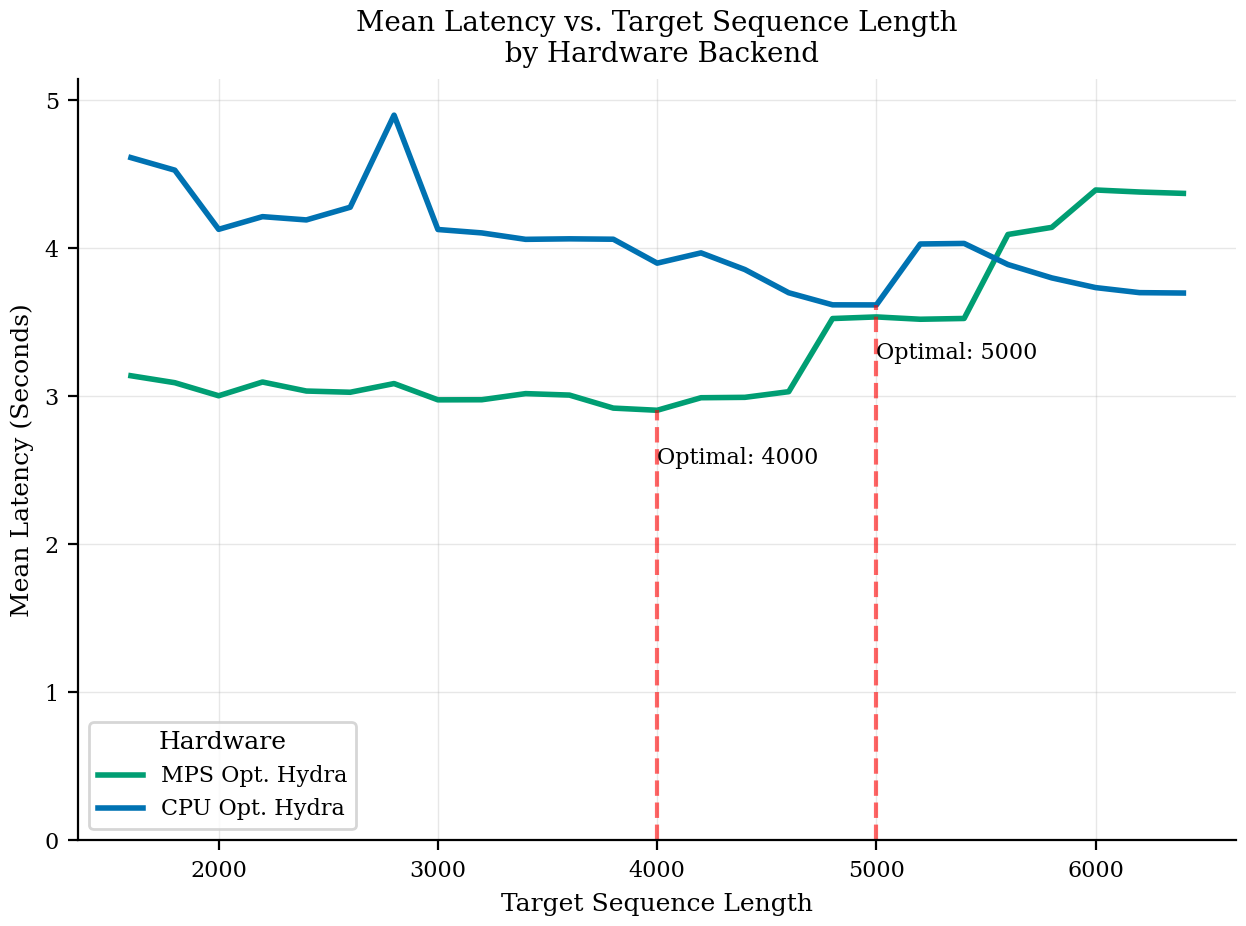

In [56]:
plot_df = optimal_seq_len.groupby(["model", "sequence_length"]).agg(
    mean_latency=("total_time", "mean")
).reset_index()

plot_df["model"] = plot_df["model"].map({"cpu_optimised_hydra": "CPU Opt. Hydra", "mps_hydra": "MPS Opt. Hydra"})
plot_df.sort_values(["model"], ascending=False, inplace=True)
hue = plot_df["model"].map(colour_map).values
# Create the main line plot
ax = sns.lineplot(
    data=plot_df,
    x="sequence_length",
    y="mean_latency",
    hue=plot_df["model"],
    palette=colour_map,
    legend="full",
    # legend="full",
    # markers=True,
    # style="model",
    dashes=False,
    linewidth=2
)

# 4. Highlight the optimal (minimum) points for each model
for model_name in plot_df['model'].unique():
    # Filter for the specific model
    model_data = plot_df[plot_df['model'] == model_name]

    # Find the row with the lowest latency
    optimal_row = model_data.loc[model_data['mean_latency'].idxmin()]
    opt_seq_len = optimal_row['sequence_length']
    opt_latency = optimal_row['mean_latency']

    # Draw a vertical dashed line down to the x-axis
    plt.vlines(x=opt_seq_len, ymin=0, ymax=opt_latency, colors='red', linestyles='dashed', alpha=0.6)

    # Add a text annotation next to the star
    plt.text(opt_seq_len, opt_latency-0.4, f'Optimal: {opt_seq_len}',
             fontsize=8, color='black', verticalalignment='bottom')

# 5. Tidy up the labels and legend
plt.title("Mean Latency vs. Target Sequence Length\n by Hardware Backend")
plt.xlabel("Target Sequence Length")
plt.ylabel("Mean Latency (Seconds)")
plt.ylim(bottom=0) # Ensure y-axis starts at 0 for fair visual comparison
plt.legend(title="Hardware")
plt.tight_layout()
plt.savefig("optimal_sequence_length.png")

plt.show()

In [ ]:
complete_results = pd.concat([summary_results[["dataset", "model", "accuracy", "total_time"]], optimised_hydra], ignore_index=True)
complete_results

,dataset,model,accuracy,total_time
0,ACSF1,hydra,0.880000,2.599249
1,ACSF1,mrsqm,0.930000,11.949221
2,Adiac,hydra,0.813299,1.377410
3,Adiac,mrsqm,0.818414,5.298092
4,AllGestureWiimoteX,hydra,0.692857,4.949160
...,...,...,...,...
507,Worms,cpu_optimised_hydra,0.740260,0.812604
508,WormsTwoClass,mps_hydra,0.766234,0.769149
509,WormsTwoClass,cpu_optimised_hydra,0.766234,0.810561
510,Yoga,mps_hydra,0.932667,3.982301
